# Hackathon - ByteCraft
---
This notebook contains the approach, design and possible solutions for the Smart India Hackathon 2026 - Problem Statement - SIH26072.

## SIH26072 - AI-ML based Nowcasting of thunderstorm and lightning using atmospheric observation including multiple radars, satellite, lightning and model data:
---
This notebook will discuss Nowcasting techniques using Machine learning and AI-models and how they can be efficient in short period forecast and weather changes without relying on large scale simulation models that can take way long to run and make predictions.

### What is **Nowcasting**?:

**Nowcasting** is a high-speed, hyper-local weather forecasting technique for immediate future - typically covering 0-6 hours.

### How is it different from standard forecasting techniques?

Standard weather forecasting techniques are for predicting the weather over a longer period like days and weeks even while Nowcasting techniques are for shorter periods to give a quick prediction of what is around the corner for the day.

> **Example Analogy:** If standard weather forecasting is like predicting where a marathon runner will be three hours from now based on their pacing and training, nowcasting is like tracking where a sprinter will step in next ten seconds by watching their balance, muscle tension and foot placement.

### Drawbacks with Traditional Weather Forecasts:

Traditional weather forecasting relies heavily on giant numerical simulations called **Numerical Weather Predictions(NWP)**. These models take observations across the entire planet, solve complex fluid dynamics and thermodynamics equations and tells us what the weather is going to be tomorrow or day after tomorrow.

While this is incredibly accurate in predicting the weather patterns on the long run - it falls short for certain sudden changes in the weather, that break predefined models - like an **anomaly** or an **edge-case**.

Thunderstroms and sudden downpours have such two characterisitcs that can break traditional models:

1. **They are short lived and localised:** A severe thunderstorm cloud can form, dump heavy rains, drop lighting and completely dissipate within 45-90 minutes across an area just 5-15 KMs wide. This is extremely difficult for a large simulation model specifically designed to predict results for a larger surface area and longer periods of time.

2. **They take too long to compute:** Gathering data, cleaning it and running large scale simulations on a global or regional supercomputer cluster takes a lot of time. By the time the forecast is calculated, the storm has hit and already vanished.

### How traditional Nowcasting works?

Instead of running slow physics simulations from scratch, traditional nowcasting operates near real time by doing these three basic operations:

1. **Where is the storm right now?**: Sensors like **Doppler radar** (which spots rain droplets and wind inside clouds) and **Satellites** (which look at cloud temperature from the space) update every 5-10 minutes.

2. **Where is it moving?**: By comparing snapshots from 10 minutes ago, 5 minutes ago and right now, algorithms calculate and storm's velocity vector and extrapolate its path forward predicting where it is going next.

3. **Is it growing, dying or about to form?**: This is the hardest part. A storm isn't moving in a straight line or have the same size (like a ball moving across a table), instead it can suddenly change direction, intensify in size, turn into a severe hailstorm or evaporate into a severe hailstorm or evaporate into thin air within 20 minutes depending on local temperature, humidity, and rising warm air.

Conventional operational nowcasting methods have been implementing three main techniques:

#### Centroid and Object Tracking:

- **Mechanism:** Algorithms identify isolated storm cells by thresholding radar reflectivity and fit them into geometric ellipsoids or polygons. **Note: Why??**

- **Tracking:** By matching centroids between sequential radar scans (every 5-10 mins) using distance minimisation or overlap, the algorithm computes a translation vector ($Δx, Δy$) and projects the polygon forward.

- **Limitation:** Treats storms as rigid objects. It struggles when cells undergo splitting, merging, or rapid spatial deformation.

#### Optical Flow and Eulerian-Lagrangian Advection:

- **Mechanisms:** Instead of tracking segmented objects, optical flow algorithms estimate a dense, 2D continous motion field ($u, v$) across every pixel of consecutive radar or satellite grids.

- **Extrapolation:** The current reflectivity field $\textit{I}(x,y,t)$ is advected forward using a semi-Lagrangian scheme along the calculated velocity vectors:

$$
\dfrac{dI}{dt} ≈ 0 \implies I(x + uΔt, y + vΔt, t + Δt) ≈ I(x,y,t)
$$

- **Stochastic Extensions:** Systems like **STEPS** decompose precipitation into spatial cascade levels (filtering by spatial frequency) and add autoregressive noise to mimic predictability decay over time.

- **Limiatations:** Pure advection assumes precipitation intensity is conserved along the motion trajectory. It is blind to **Convective Initiation(CI)** (birth of new cells) and **dissipation** (cell decay).

#### Rapid Update Convective-Allowing Models (CAMs):

**Mechanism:** Running localised, non-hydrostatic numerical weather prediction (NWP) models (e.g: HRRR, localised WRF) with grid spacings of 1-3 KMs and frequent data assimilation cycles (hourly or sub-hourly).

**Limitations:**
1. **Latency:** Data assimilation and running differential equations still take a long time.

2. **Spin-up Error:** Newly ingested radar echoes can take 15-30 simulation minutes to balance with model microphysics and thermodynamics, during which precipitation forecasts are unreliable.

### Nowcasting with AI and Machine/Deep Learning Methods:

Machine/Deep Learning models can modernise by moving beyong simple kinematic motion tracking to learning the non-linear, multi-scale physical evolution of convective systems directly from multi-modal sensor streams.

#### **Traditional Nowcating Flow:**

<img src="flow1.png" alt="Traditional Nowcasting Pipeline" width="1000">

#### **Modern AI Flow:**

<img src="flow2.png" alt="Traditional Nowcasting Pipeline" width="1000">

#### Objectives of Nowcasting using ML/DL Methods:

1. Fast and Accurate: 
2. Scalability:

## Prototype Architecture: ConvLSTM + UNet:

**U-Net** - Spatial Feature Extraction.
**ConvLSTM** - Spatiotemporal Memory.

### U-Net (Spatial Specialist):
Originally desgined for image segmentation, 

In [1]:
import torch
import torch.nn as nn
import numpy as np

# ---------------------------------------------------------
# 1. SYNTHETIC RADAR DATA GENERATOR
# ---------------------------------------------------------
def generate_storm_sequence(batch_size=4, total_seq=6, size=64):
    """
    Generates synthetic 'radar' sequences of a moving storm cell.
    Returns tensor of shape: (batch_size, total_seq, channels(1), width, height)
    """
    data = np.zeros((batch_size, total_seq, 1, size, size), dtype=np.float32)
    
    for b in range(batch_size):
        # Spawn a storm at a random starting coordinate
        x, y = np.random.randint(10, 30), np.random.randint(10, 30)
        
        # Give the storm a random velocity (wind vector)
        vx, vy = np.random.uniform(1, 3), np.random.uniform(1, 3)
        
        for t in range(total_seq):
            # Create a 2D coordinate grid
            X, Y = np.meshgrid(np.arange(size), np.arange(size))
            
            # Draw the storm as a Gaussian blob (heat map)
            blob = np.exp(-(((X - x)**2 + (Y - y)**2) / 20.0))
            data[b, t, 0, :, :] = blob
            
            # Advect (move) the storm forward in time
            x += vx
            y += vy
            
    return torch.tensor(data)

# ---------------------------------------------------------
# 2. THE MODEL: CONVLSTM CELL
# ---------------------------------------------------------
class ConvLSTMCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size):
        super().__init__()
        self.hidden_dim = hidden_dim
        padding = kernel_size // 2
        
        # One large convolution handles all four LSTM gates simultaneously
        self.conv = nn.Conv2d(in_channels=input_dim + hidden_dim,
                              out_channels=4 * hidden_dim,
                              kernel_size=kernel_size, 
                              padding=padding)

    def forward(self, input_tensor, cur_state):
        h_cur, c_cur = cur_state
        
        # Stack the new radar frame with the hidden memory state
        combined = torch.cat([input_tensor, h_cur], dim=1)
        combined_conv = self.conv(combined)
        
        # Split the tensor into the 4 LSTM gates
        cc_i, cc_f, cc_o, cc_g = torch.split(combined_conv, self.hidden_dim, dim=1)
        
        i = torch.sigmoid(cc_i)      # Input gate: What new data to keep?
        f = torch.sigmoid(cc_f)      # Forget gate: What old memory to drop?
        o = torch.sigmoid(cc_o)      # Output gate: What to show next?
        g = torch.tanh(cc_g)         # Cell update: New candidate memory
        
        c_next = f * c_cur + i * g
        h_next = o * torch.tanh(c_next)
        
        return h_next, c_next

# ---------------------------------------------------------
# 3. THE NOWCASTER & TRAINING LOOP
# ---------------------------------------------------------
class SimpleNowcaster(nn.Module):
    def __init__(self):
        super().__init__()
        # 1 input channel (radar), 16 hidden channels (memory), 3x3 kernel
        self.cell = ConvLSTMCell(input_dim=1, hidden_dim=16, kernel_size=3)
        # Collapse the 16 hidden channels back down to 1 grayscale radar image
        self.conv_out = nn.Conv2d(16, 1, kernel_size=1)

    def forward(self, x):
        b, seq, _, h, w = x.size()
        
        # Initialize blank memory states
        h_t = torch.zeros(b, 16, h, w).to(x.device)
        c_t = torch.zeros(b, 16, h, w).to(x.device)
        
        # Read the past radar sequence frame by frame
        for t in range(seq):
            h_t, c_t = self.cell(x[:, t, :, :, :], (h_t, c_t))
            
        # Generate the prediction for the future frame
        prediction = self.conv_out(h_t)
        return torch.sigmoid(prediction)

if __name__ == "__main__":
    print("1. Generating synthetic storm dataset...")
    # Generate 6 frames total: 5 for past context, 1 for the future target
    dataset = generate_storm_sequence(batch_size=16, total_seq=6, size=64)
    past_radar = dataset[:, :5]   # Input: Frames 0 to 4
    future_radar = dataset[:, 5]  # Target: Frame 5

    model = SimpleNowcaster()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.MSELoss()

    print("2. Training ConvLSTM to predict movement...")
    for epoch in range(1, 101):
        optimizer.zero_grad()
        
        # The model guesses where the storm will be
        pred = model(past_radar)
        
        # We penalize it based on how far off the guess was from reality
        loss = criterion(pred, future_radar)
        loss.backward()
        optimizer.step()
        
        if epoch % 20 == 0:
            print(f"Epoch {epoch:03d} | Mean Squared Error Loss: {loss.item():.4f}")
            
    print("\nTraining Complete! The network has learned how to track and advect spatial objects.")

1. Generating synthetic storm dataset...
2. Training ConvLSTM to predict movement...
Epoch 020 | Mean Squared Error Loss: 0.0077
Epoch 040 | Mean Squared Error Loss: 0.0074
Epoch 060 | Mean Squared Error Loss: 0.0074
Epoch 080 | Mean Squared Error Loss: 0.0074
Epoch 100 | Mean Squared Error Loss: 0.0074

Training Complete! The network has learned how to track and advect spatial objects.


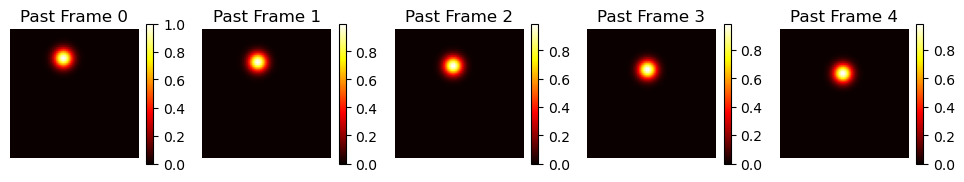

In [ ]:
## Let's visualize the results of the nowcaster on a random sample from the dataset:
random_index = np.random.randint(0, dataset.size(0))
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
# Plot the past radar frames
for t in range(5):
    plt.subplot(2, 5, t + 1)
    plt.imshow(past_radar[random_index, t, 0].detach().numpy(), cmap='hot')
    plt.title(f"Past Frame {t}")
    plt.axis('off')
    plt.colorbar()

Initializing ConvLSTM-UNet Model...
Training on synthetic multi-modal data...
Epoch 010 | MSE Loss: 0.0061
Epoch 020 | MSE Loss: 0.0058
Epoch 030 | MSE Loss: 0.0058
Epoch 040 | MSE Loss: 0.0058

Training Complete! Plotting test prediction...


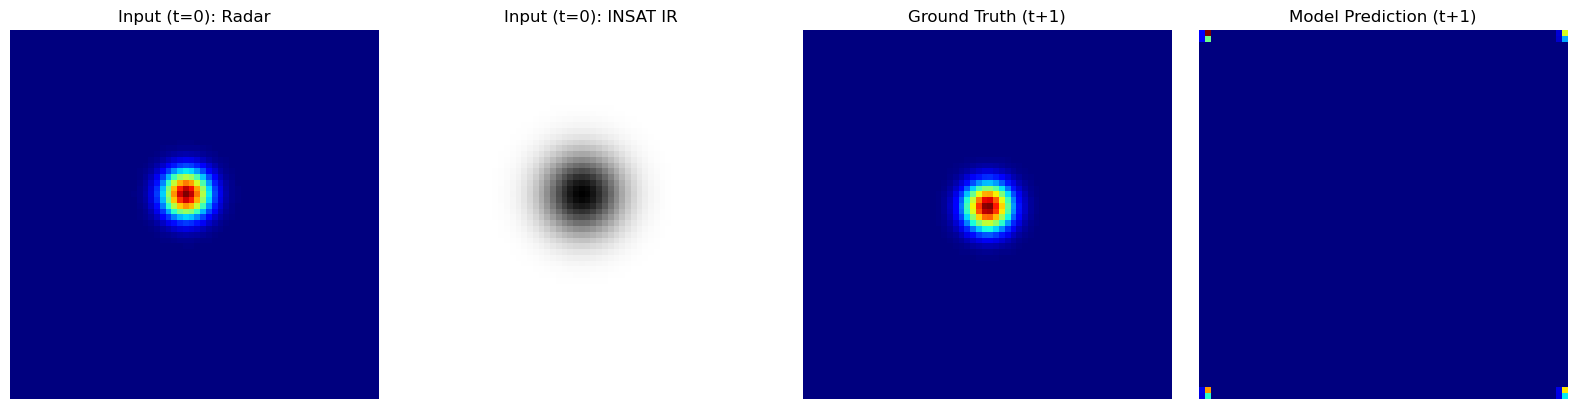

In [5]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. MULTI-MODAL SYNTHETIC DATA GENERATOR
# ---------------------------------------------------------
def generate_multimodal_storms(batch_size=4, seq_len=5, size=64):
    """
    Channels:
    0 - Doppler Radar (Compact, high intensity cores)
    1 - INSAT-3DS Thermal IR (Broad, diffused cold cloud shields)
    2 - Lightning Flash Density (Sparse spikes inside radar cores)
    """
    # (Batch, Sequence, Channels, Height, Width)
    data = np.zeros((batch_size, seq_len, 3, size, size), dtype=np.float32)
    
    for b in range(batch_size):
        # Spawn storm at random location with random wind vector
        x, y = np.random.randint(15, 25), np.random.randint(15, 25)
        vx, vy = np.random.uniform(1.5, 2.5), np.random.uniform(1.5, 2.5)
        
        for t in range(seq_len):
            X, Y = np.meshgrid(np.arange(size), np.arange(size))
            
            # Ch 0: Radar (Tight Gaussian blob)
            radar = np.exp(-(((X - x)**2 + (Y - y)**2) / 15.0))
            
            # Ch 1: INSAT-3DS IR (Wider blob, representing spreading anvil cloud)
            ir = np.exp(-(((X - x)**2 + (Y - y)**2) / 45.0))
            
            # Ch 2: Lightning (Random strikes localized near radar core)
            lightning = np.zeros((size, size))
            if np.random.rand() > 0.3: # 70% chance of lightning in this frame
                lx, ly = int(x + np.random.randint(-2, 2)), int(y + np.random.randint(-2, 2))
                if 0 <= lx < size and 0 <= ly < size:
                    lightning[ly, lx] = 1.0
            
            data[b, t, 0] = radar
            data[b, t, 1] = ir
            data[b, t, 2] = lightning
            
            x += vx
            y += vy
            
    return torch.tensor(data)

# ---------------------------------------------------------
# 2. CONVLSTM CELL (THE BOTTLENECK)
# ---------------------------------------------------------
class ConvLSTMCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size=3):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.conv = nn.Conv2d(input_dim + hidden_dim, 4 * hidden_dim, kernel_size, padding=kernel_size//2)

    def forward(self, x, state):
        h, c = state
        combined = torch.cat([x, h], dim=1)
        gates = self.conv(combined)
        i, f, o, g = torch.split(gates, self.hidden_dim, dim=1)
        
        c_next = torch.sigmoid(f) * c + torch.sigmoid(i) * torch.tanh(g)
        h_next = torch.sigmoid(o) * torch.tanh(c_next)
        return h_next, c_next

# ---------------------------------------------------------
# 3. CONVLSTM-UNET ARCHITECTURE
# ---------------------------------------------------------
class UNet_ConvLSTM(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()
        # --- ENCODER (Spatial Compression) ---
        self.enc1 = nn.Sequential(nn.Conv2d(in_channels, 16, 3, padding=1), nn.ReLU())
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = nn.Sequential(nn.Conv2d(16, 32, 3, padding=1), nn.ReLU())
        self.pool2 = nn.MaxPool2d(2)
        
        # --- BOTTLENECK (Temporal Memory) ---
        # 32 channels in, 32 hidden channels out, running at 16x16 resolution
        self.convlstm = ConvLSTMCell(input_dim=32, hidden_dim=32)
        
        # --- DECODER (Spatial Expansion & Skip Connections) ---
        self.up1 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        self.dec1 = nn.Sequential(nn.Conv2d(32, 16, 3, padding=1), nn.ReLU()) # 32 due to skip connection
        
        self.up2 = nn.ConvTranspose2d(16, 16, kernel_size=2, stride=2)
        self.final = nn.Conv2d(16+16, out_channels, kernel_size=1) # 16+16 from skip connection

    def forward(self, seq):
        batch, time_steps, C, H, W = seq.size()
        
        # Initialize hidden states for 16x16 bottleneck
        h_t = torch.zeros(batch, 32, H//4, W//4, device=seq.device)
        c_t = torch.zeros(batch, 32, H//4, W//4, device=seq.device)
        
        # Process each time step
        for t in range(time_steps):
            x = seq[:, t]
            
            # Encode
            e1 = self.enc1(x)
            e1_pool = self.pool1(e1)
            e2 = self.enc2(e1_pool)
            e2_pool = self.pool2(e2)
            
            # Update temporal memory
            h_t, c_t = self.convlstm(e2_pool, (h_t, c_t))
            
        # Decode the final hidden state to predict the next frame
        d1 = self.up1(h_t)
        # Skip connection: attach the spatial features from the very last input frame
        d1_skip = torch.cat([d1, e1_pool], dim=1) 
        d1_out = self.dec1(d1_skip)
        
        d2 = self.up2(d1_out)
        d2_skip = torch.cat([d2, self.enc1(seq[:, -1])], dim=1)
        
        out = torch.sigmoid(self.final(d2_skip))
        return out

# ---------------------------------------------------------
# 4. TRAINING LOOP & VISUALIZATION
# ---------------------------------------------------------
if __name__ == "__main__":
    print("Initializing ConvLSTM-UNet Model...")
    model = UNet_ConvLSTM(in_channels=3, out_channels=1) # Predicts 1 channel (Future Radar)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
    criterion = nn.MSELoss()

    epochs = 40
    print("Training on synthetic multi-modal data...")
    for epoch in range(1, epochs + 1):
        # Generate 5 past frames and 1 future target frame (just radar)
        data = generate_multimodal_storms(batch_size=8, seq_len=6, size=64)
        x_past = data[:, :5, :, :, :]    # 5 frames of Radar, IR, Lightning
        y_future = data[:, 5, 0:1, :, :] # 1 future frame of Radar only
        
        optimizer.zero_grad()
        pred = model(x_past)
        loss = criterion(pred, y_future)
        loss.backward()
        optimizer.step()
        
        if epoch % 10 == 0:
            print(f"Epoch {epoch:03d} | MSE Loss: {loss.item():.4f}")

    print("\nTraining Complete! Plotting test prediction...")
    
    # Test on a new sequence
    test_data = generate_multimodal_storms(batch_size=1, seq_len=6, size=64)
    x_test = test_data[:, :5]
    y_true = test_data[0, 5, 0].detach().numpy()
    y_pred = model(x_test)[0, 0].detach().numpy()

    # Visualize
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(x_test[0, 4, 0], cmap='jet')
    axes[0].set_title("Input (t=0): Radar")
    axes[1].imshow(x_test[0, 4, 1], cmap='gray_r')
    axes[1].set_title("Input (t=0): INSAT IR")
    axes[2].imshow(y_true, cmap='jet')
    axes[2].set_title("Ground Truth (t+1)")
    axes[3].imshow(y_pred, cmap='jet')
    axes[3].set_title("Model Prediction (t+1)")
    
    for ax in axes: ax.axis('off')
    plt.tight_layout()
    plt.show()

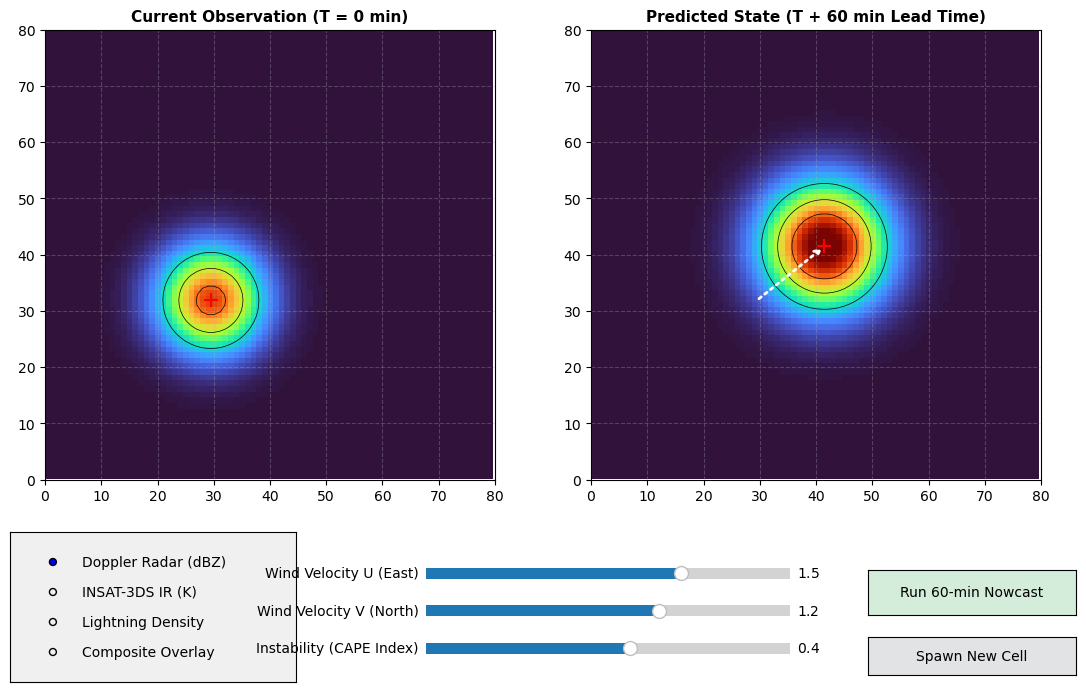

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button, RadioButtons
import matplotlib.animation as animation

# ---------------------------------------------------------
# 1. SYNTHETIC MULTI-MODAL WEATHER ENGINE
# ---------------------------------------------------------
class ConvectiveStormSimulator:
    def __init__(self, grid_size=80):
        self.grid_size = grid_size
        self.reset_storm()

    def reset_storm(self):
        # Initial storm position near bottom-left/center
        self.x0 = np.random.uniform(20, 35)
        self.y0 = np.random.uniform(20, 35)
        self.base_intensity = 55.0  # Peak Radar Reflectivity (dBZ)
        self.base_radius = 6.0      # Spatial footprint

    def compute_fields(self, t_step, vx, vy, instability):
        """
        Generates physical fields at lead-time t_step (0 = now, t > 0 = future).
        Instability acts as a proxy for CAPE (positive = cell growth, negative = decay).
        """
        x = self.x0 + vx * t_step
        y = self.y0 + vy * t_step

        # Growth / decay dynamics over time
        growth_factor = 1.0 + (instability * 0.12 * t_step)
        growth_factor = max(0.05, growth_factor)

        radius = self.base_radius * np.sqrt(growth_factor)
        intensity = np.clip(self.base_intensity * growth_factor, 0, 70)

        # Coordinate grid
        Y, X = np.ogrid[:self.grid_size, :self.grid_size]
        dist_sq = (X - x)**2 + (Y - y)**2

        # 1. Doppler Radar (dBZ) - Concentrated convective core
        radar = intensity * np.exp(-dist_sq / (2.0 * (radius**2)))
        radar = np.clip(radar, 0, 70)

        # 2. INSAT-3DS Thermal IR (10.8 µm in Kelvin) - Cold cloud-top anvil shield
        # Cooler temperatures (e.g., 200K) correspond to high convective tops
        cloud_radius = radius * 2.2
        ir_cooling = (285 - 195) * np.exp(-dist_sq / (2.0 * (cloud_radius**2)))
        insat_ir = 285.0 - (ir_cooling * min(growth_factor, 1.4))

        # 3. Lightning Flash Density (flashes / km² / min)
        # Initiates strongly only when radar core exceeds 38-40 dBZ (mixed-phase zone)
        lightning = np.zeros((self.grid_size, self.grid_size))
        if intensity > 35:
            num_flashes = int(max(0, (intensity - 35) * 1.5 * growth_factor))
            for _ in range(num_flashes):
                fx = int(np.clip(np.random.normal(x, radius * 0.6), 0, self.grid_size - 1))
                fy = int(np.clip(np.random.normal(y, radius * 0.6), 0, self.grid_size - 1))
                lightning[fy, fx] += 1.0

        return radar, insat_ir, lightning, (x, y)

# ---------------------------------------------------------
# 2. INTERACTIVE DASHBOARD GUI
# ---------------------------------------------------------
class NowcastDashboard:
    def __init__(self):
        self.sim = ConvectiveStormSimulator(grid_size=80)
        self.active_layer = "Doppler Radar (dBZ)"
        self.anim = None
        self.is_animating = False

        # Build figure and layout
        self.fig = plt.figure(figsize=(13, 7.5))
        self.fig.canvas.manager.set_window_title("Multi-Modal AI Nowcasting Engine")

        # Two main display panels
        self.ax_obs = plt.axes([0.06, 0.32, 0.40, 0.60])
        self.ax_pred = plt.axes([0.48, 0.32, 0.40, 0.60])

        self.setup_ui_controls()
        self.update_views()

    def setup_ui_controls(self):
        # 1. Layer Selection
        ax_radio = plt.axes([0.06, 0.05, 0.22, 0.20], facecolor="#f0f0f0")
        self.radio = RadioButtons(ax_radio, (
            "Doppler Radar (dBZ)", 
            "INSAT-3DS IR (K)", 
            "Lightning Density", 
            "Composite Overlay"
        ))
        self.radio.on_clicked(self.on_layer_change)

        # 2. Sliders for Atmospheric Variables
        ax_vx = plt.axes([0.38, 0.18, 0.28, 0.03])
        ax_vy = plt.axes([0.38, 0.13, 0.28, 0.03])
        ax_instability = plt.axes([0.38, 0.08, 0.28, 0.03])

        self.slider_vx = Slider(ax_vx, "Wind Velocity U (East)", -2.0, 3.0, valinit=1.5, valstep=0.1)
        self.slider_vy = Slider(ax_vy, "Wind Velocity V (North)", -2.0, 3.0, valinit=1.2, valstep=0.1)
        self.slider_inst = Slider(ax_instability, "Instability (CAPE Index)", -1.0, 1.5, valinit=0.4, valstep=0.05)

        self.slider_vx.on_changed(self.on_slider_change)
        self.slider_vy.on_changed(self.on_slider_change)
        self.slider_inst.on_changed(self.on_slider_change)

        # 3. Action Buttons
        ax_btn_run = plt.axes([0.72, 0.14, 0.16, 0.06])
        ax_btn_reset = plt.axes([0.72, 0.06, 0.16, 0.05])

        self.btn_run = Button(ax_btn_run, "Run 60-min Nowcast", color="#d4edda", hovercolor="#c3e6cb")
        self.btn_reset = Button(ax_btn_reset, "Spawn New Cell", color="#e2e3e5", hovercolor="#d6d8db")

        self.btn_run.on_clicked(self.start_nowcast_animation)
        self.btn_reset.on_clicked(self.on_reset)

    def render_layer(self, ax, radar, ir, lightning, title, center):
        ax.clear()
        ax.set_title(title, fontsize=11, fontweight="bold")
        ax.set_xlim(0, self.sim.grid_size)
        ax.set_ylim(0, self.sim.grid_size)

        if self.active_layer == "Doppler Radar (dBZ)":
            im = ax.imshow(radar, cmap="turbo", origin="lower", vmin=0, vmax=65)
            ax.contour(radar, levels=[20, 35, 50], colors="black", linewidths=0.5)
        elif self.active_layer == "INSAT-3DS IR (K)":
            im = ax.imshow(ir, cmap="Blues_r", origin="lower", vmin=195, vmax=285)
        elif self.active_layer == "Lightning Density":
            im = ax.imshow(lightning, cmap="hot", origin="lower", vmin=0, vmax=3)
        elif self.active_layer == "Composite Overlay":
            # IR as background cold shield, radar cores contoured, lightning plotted as markers
            im = ax.imshow(ir, cmap="gray_r", origin="lower", vmin=195, vmax=285, alpha=0.85)
            ax.contour(radar, levels=[30, 45], cmap="autumn", linewidths=1.5)
            y_pts, x_pts = np.where(lightning > 0)
            ax.scatter(x_pts, y_pts, color="cyan", s=25, marker="x", label="Flash Events")
            ax.legend(loc="upper right", fontsize=8)

        # Draw storm center point
        ax.plot(center[0], center[1], "r+", markersize=10, markeredgewidth=1.5)
        ax.grid(True, linestyle="--", alpha=0.3)

    def update_views(self):
        vx = self.slider_vx.val
        vy = self.slider_vy.val
        inst = self.slider_inst.val

        # Current Observation (T = 0)
        r0, ir0, l0, c0 = self.sim.compute_fields(0, vx, vy, inst)
        self.render_layer(self.ax_obs, r0, ir0, l0, "Current Observation (T = 0 min)", c0)

        # Forecast Window (T + 60 min)
        r_f, ir_f, l_f, c_f = self.sim.compute_fields(8, vx, vy, inst)
        self.render_layer(self.ax_pred, r_f, ir_f, l_f, "Predicted State (T + 60 min Lead Time)", c_f)

        # Draw extrapolation trajectory vector
        self.ax_pred.annotate("", xy=c_f, xytext=c0,
                              arrowprops=dict(arrowstyle="->", color="white", lw=2, linestyle=":"))

        self.fig.canvas.draw_idle()

    def on_layer_change(self, label):
        self.active_layer = label
        self.update_views()

    def on_slider_change(self, val):
        if not self.is_animating:
            self.update_views()

    def on_reset(self, event):
        self.sim.reset_storm()
        self.update_views()

    def start_nowcast_animation(self, event):
        if self.is_animating:
            return

        self.is_animating = True
        vx = self.slider_vx.val
        vy = self.slider_vy.val
        inst = self.slider_inst.val

        steps = 12  # 0 to 60 minutes in 5-minute intervals

        def animate(frame):
            r_t, ir_t, l_t, c_t = self.sim.compute_fields(frame * (8.0 / steps), vx, vy, inst)
            minutes = int(frame * (60.0 / steps))
            self.render_layer(
                self.ax_pred, r_t, ir_t, l_t, 
                f"Model Nowcasting Rolling Output (T + {minutes} min)", c_t
            )
            if frame == steps:
                self.is_animating = False

        self.anim = animation.FuncAnimation(
            self.fig, animate, frames=range(steps + 1), interval=150, repeat=False
        )
        self.fig.canvas.draw_idle()

# ---------------------------------------------------------
# 3. LAUNCH APPLICATION
# ---------------------------------------------------------
if __name__ == "__main__":
    app = NowcastDashboard()
    plt.show()